In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

In [7]:
df = pd.read_csv("dataset.csv")

In [8]:
df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
DiseaseAndSymptoms = {
"Fungal infection":[
    'itching', 'skin_rash', 'pus_filled_pimples', 'skin_peeling',
    'dischromic _patches', 'blister', 'red_sore_around_nose',
    'internal_itching', 'blackheads', 'nodal_skin_eruptions'
],
"Allergy":[
    'itching','skin_rash','continuous_sneezing','shivering','fatigue','redness_of_eyes','watering_from_eyes','runny_nose','congestion','cough'
],
"GERD":[
    'chest_pain','stomach_pain','acidity','vomiting','indigestion','cough','pain_in_anal_region','burning_micturition','abdominal_pain'
],
"Chronic cholestasis":[
    'itching', 'fatigue', 'yellowish_skin', 'dark_urine',
    'nausea', 'loss_of_appetite', 'abdominal_pain', 'yellowing_of_eyes'
],
"Drug Reaction":[
    'itching', 'skin_rash', 'nausea', 'vomiting',
    'fatigue', 'high_fever', 'malaise',
    'red_spots_over_body'
],
"Peptic ulcer diseae":[
    'abdominal_pain', 'vomiting', 'indigestion', 'loss_of_appetite',
    'passage_of_gases', 'internal_itching', 'chest_pain', 'nausea',
    'bloody_stool', 'pain_in_anal_region'
],
"AIDS":[
    'weight_loss', 'fatigue', 'high_fever', 'muscle_wasting',
    'pus_filled_pimples', 'skin_rash', 'loss_of_appetite',
    'malaise', 'swelled_lymph_nodes', 'extra_marital_contacts'
],
"Diabetes ":[
    'fatigue', 'weight_loss', 'increased_appetite', 'excessive_hunger',
    'polyuria', 'blurred_and_distorted_vision', 'irregular_sugar_level',
    'obesity', 'lack_of_concentration', 'lethargy'
],
"Gastroenteritis":[
    'vomiting', 'diarrhoea', 'stomach_pain', 'nausea',
    'dehydration', 'loss_of_appetite',
    'abdominal_pain', 'cramps', 'mild_fever'
],
"Bronchial Asthma":[
    'chest_pain', 'cough', 'breathlessness', 'fatigue',
    'mucoid_sputum', 'restlessness',
    'fast_heart_rate'
],
"Hypertension ":[
    'headache', 'chest_pain', 'dizziness', 'blurred_and_distorted_vision',
    'fatigue', 'irregular_sugar_level', 'palpitations',
    'breathlessness', 'nausea'
],
"Migraine":[
    'headache', 'nausea', 'vomiting', 'visual_disturbances',
     'fatigue', 'pain_behind_the_eyes',
    'irritability', 'slurred_speech'
],
"Cervical spondylosis":[
    'neck_pain', 'dizziness', 'back_pain', 'weakness_in_limbs',
    'headache', 'stiff_neck', 'loss_of_balance', 'painful_walking'
],
"Paralysis (brain hemorrhage)":[
    'weakness_of_one_body_side', 'slurred_speech', 'loss_of_balance',
    'headache', 'nausea', 'altered_sensorium', 'unsteadiness',
    'vomiting', 'dizziness', 'coma'
],
"Jaundice":[
    'yellowish_skin', 'dark_urine', 'itching', 'fatigue',
    'nausea', 'vomiting', 'abdominal_pain', 'loss_of_appetite',
    'yellowing_of_eyes'
]
,
"Malaria":[
    'shivering', 'chills', 'vomiting', 'high_fever',
    'sweating', 'headache', 'nausea', 'fatigue',
    'muscle_pain'
],
"Chicken pox":[
    'itching', 'skin_rash', 'high_fever', 'fatigue',
    'lethargy', 'headache', 'loss_of_appetite',
    'red_spots_over_body', 'mild_fever', 'blister'
],
"Dengue":[
    'high_fever', 'headache', 'muscle_pain', 'joint_pain',
    'nausea', 'vomiting', 'fatigue', 'skin_rash',
    'red_spots_over_body', 'pain_behind_the_eyes'
],
"Typhoid":[
    'high_fever', 'fatigue', 'abdominal_pain', 'diarrhoea',
    'headache', 'loss_of_appetite', 'toxic_look_(typhos)',
    'nausea', 'constipation', 'malaise'
],
"hepatitis A":[
    'yellowing_of_eyes', 'dark_urine', 'loss_of_appetite', 'fatigue',
    'abdominal_pain', 'nausea', 'vomiting',
    'itching', 'mild_fever'
],
"Hepatitis B":[
    'fatigue', 'loss_of_appetite', 'yellowish_skin', 'dark_urine',
    'abdominal_pain', 'joint_pain', 'nausea', 'vomiting',
    'yellowing_of_eyes'
],
"Hepatitis C":[
    'fatigue', 'abdominal_pain', 'yellowish_skin', 'nausea',
    'loss_of_appetite', 'dark_urine',
    'joint_pain'
],
"Hepatitis D":[
    'fatigue', 'abdominal_pain', 'vomiting', 'loss_of_appetite', 'yellowing_of_eyes', 'dark_urine',
    'yellowish_skin', 'nausea'
],
"Hepatitis E":[
    'nausea', 'vomiting', 'fatigue', 'abdominal_pain', 'yellowing_of_eyes', 'dark_urine',
    'loss_of_appetite', 'mild_fever'
],
"Alcoholic hepatitis":[
    'fatigue', 'loss_of_appetite', 'abdominal_pain', 'yellowish_skin',
    'yellowing_of_eyes', 'vomiting', 'nausea', 'dark_urine',
    'history_of_alcohol_consumption', 'distention_of_abdomen'
],
"Tuberculosis":[
    'cough', 'fatigue', 'weight_loss', 'high_fever',
    'chest_pain', 'breathlessness', 'loss_of_appetite',
    'malaise', 'sweating', 'blood_in_sputum'
],
"Common Cold":[
    'continuous_sneezing', 'chills', 'fatigue', 'cough',
    'high_fever', 'headache', 'congestion', 'runny_nose',
    'redness_of_eyes', 'throat_irritation'
],
"Pneumonia":[
    'chest_pain', 'cough', 'high_fever', 'breathlessness',
    'sweating', 'malaise', 'fatigue', 'phlegm',
    'fast_heart_rate', 'rusty_sputum'
],
"Dimorphic hemmorhoids(piles)":[
    'pain_in_anal_region', 'bloody_stool', 'constipation',
    'abdominal_pain', 'irritation_in_anus', 'swelling_of_stomach',
    'cramps'
],
"Heart attack":[
    'chest_pain', 'sweating', 'fatigue', 'breathlessness',
    'nausea', 'vomiting', 'dizziness', 'fast_heart_rate',
    'pain_in_anal_region'
],
"Varicose veins":[
    'swollen_legs', 'painful_walking', 'fatigue', 'cramps',
    'prominent_veins_on_calf', 'swelling_joints', 'bruising'
],
"Hypothyroidism":[
    'fatigue', 'weight_gain', 'cold_hands_and_feets', 'depression',
    'lethargy', 'obesity', 'irritability', 'drying_and_tingling_lips',
    'enlarged_thyroid', 'brittle_nails'
],
"Hyperthyroidism":[
    'weight_loss', 'increased_appetite', 'irritability', 'sweating',
    'fast_heart_rate', 'excessive_hunger', 'enlarged_thyroid',
    'anxiety', 'visual_disturbances'
],
"Hypoglycemia":[
    'excessive_hunger', 'sweating', 'dizziness', 'lethargy',
    'irritability', 'palpitations', 'slurred_speech',
    'loss_of_balance', 'lack_of_concentration'
],
"Osteoarthristis":[
    'joint_pain', 'swelling_joints', 'movement_stiffness',
    'painful_walking', 'back_pain', 'knee_pain', 'hip_joint_pain'
],
"Arthritis":[
    'joint_pain', 'swelling_joints', 'painful_walking', 'stiff_neck',
    'weakness_in_limbs', 'fatigue', 'inflammatory_nails'
],
"(vertigo) Paroymsal  Positional Vertigo":[
    'spinning_movements', 'loss_of_balance', 'unsteadiness',
    'nausea', 'headache', 'blurred_and_distorted_vision',
    'vomiting'
],
"Acne":[
    'skin_rash', 'pus_filled_pimples', 'blackheads',
    'scurring', 'inflammatory_nails'
],
"Urinary tract infection":[
    'burning_micturition', 'bladder_discomfort', 'foul_smell_of urine',
    'continuous_feel_of_urine', 'spotting_ urination', 'pain_during_bowel_movements',
    'abdominal_pain'
],
"Psoriasis":[
    'skin_rash', 'scurring', 'silver_like_dusting',
    'skin_peeling', 'inflammatory_nails', 'small_dents_in_nails',
    'joint_pain'
],
"Impetigo":[
    'skin_rash', 'red_sore_around_nose', 'blister',
    'pus_filled_pimples', 'yellow_crust_ooze'
]
}

In [16]:
import random

# Loop through each disease and its symptoms
for key, value in DiseaseAndSymptoms.items():
    reqsymptoms = df[df['Disease'] == key].index

    for idx in reqsymptoms:
        # Get existing symptoms in the row (ignore NaNs and strip spaces)
        existing_symptoms = [str(df.at[idx, f'Symptom_{i}']).strip() 
                             for i in range(1, 18) 
                             if pd.notna(df.at[idx, f'Symptom_{i}'])]

        # Choose random symptoms from the value list
        num_symptoms = random.randint(4, len(value))
        selected_symptoms = random.sample(value, num_symptoms)

        for symptom in selected_symptoms:
            # If symptom is already in row, skip
            if symptom in existing_symptoms:
                continue
            
            # Find the first empty symptom column and insert the new symptom
            for i in range(1, 18):
                col = f'Symptom_{i}'
                if pd.isna(df.at[idx, col]) or df.at[idx, col] == '':
                    df.at[idx, col] = symptom
                    existing_symptoms.append(symptom)  # Update the existing list
                    break  # Go to the next symptom


In [17]:
df.head

<bound method NDFrame.head of                                       Disease             Symptom_1  \
0                            Fungal infection               itching   
1                            Fungal infection             skin_rash   
2                            Fungal infection               itching   
3                            Fungal infection               itching   
4                            Fungal infection               itching   
...                                       ...                   ...   
4915  (vertigo) Paroymsal  Positional Vertigo              vomiting   
4916                                     Acne             skin_rash   
4917                  Urinary tract infection   burning_micturition   
4918                                Psoriasis             skin_rash   
4919                                 Impetigo             skin_rash   

                  Symptom_2              Symptom_3                  Symptom_4  \
0                 skin_rash   nodal_

In [19]:
df.to_csv("new_added_list.csv", index = False)

### Now using the new dataset

In [33]:
df_new = pd.read_csv("new_dataset.csv")

In [34]:
df_new.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,blackheads,skin_peeling,blister,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,internal_itching,skin_peeling,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,blister,skin_rash,blackheads,pus_filled_pimples,red_sore_around_nose,skin_peeling,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,blackheads,blister,nodal_skin_eruptions,skin_peeling,internal_itching,red_sore_around_nose,pus_filled_pimples,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,skin_peeling,dischromic_patches,blackheads,internal_itching,blister,red_sore_around_nose,pus_filled_pimples,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
df_new = df_new.replace('spotting_ urination', 'spotting_urination')

In [30]:
df_new.to_csv("new_dataset.csv",index = False)

In [32]:
print('spotting_urination' in df_new.values)  # Should return True

True


In [35]:
symptom_cols = [f"Symptom_{i}" for i in range(1, 18)]

In [36]:
symptom_cols

['Symptom_1',
 'Symptom_2',
 'Symptom_3',
 'Symptom_4',
 'Symptom_5',
 'Symptom_6',
 'Symptom_7',
 'Symptom_8',
 'Symptom_9',
 'Symptom_10',
 'Symptom_11',
 'Symptom_12',
 'Symptom_13',
 'Symptom_14',
 'Symptom_15',
 'Symptom_16',
 'Symptom_17']

In [37]:
df_new[symptom_cols] = df_new[symptom_cols].fillna('').apply(lambda col: col.str.strip())

In [40]:
df_new['SymptomText'] = df_new[symptom_cols].apply(lambda row: ','.join([sym for sym in row if sym]), axis=1)

In [41]:
df_new['SymptomText']

0       itching,skin_rash,nodal_skin_eruptions,dischro...
1       skin_rash,nodal_skin_eruptions,dischromic _pat...
2       itching,nodal_skin_eruptions,dischromic _patch...
3       itching,skin_rash,dischromic _patches,blackhea...
4       itching,skin_rash,nodal_skin_eruptions,skin_pe...
                              ...                        
4915    vomiting,headache,nausea,spinning_movements,lo...
4916    skin_rash,pus_filled_pimples,blackheads,scurri...
4917    burning_micturition,bladder_discomfort,foul_sm...
4918    skin_rash,joint_pain,skin_peeling,silver_like_...
4919    skin_rash,high_fever,blister,red_sore_around_n...
Name: SymptomText, Length: 4920, dtype: object

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the vectorizer
vectorizer = TfidfVectorizer()

# Transform symptoms into TF-IDF matrix
X = vectorizer.fit_transform(df_new['SymptomText'])

In [43]:
print(X)

  (0, 58)	0.2376751331290969
  (0, 103)	0.22527035595453415
  (0, 76)	0.4092768628433913
  (0, 33)	0.4176246213045846
  (0, 0)	0.4176246213045846
  (0, 9)	0.36406012350551065
  (0, 102)	0.36278011450232195
  (0, 11)	0.33509164972660016
  (1, 103)	0.24699064924471098
  (1, 76)	0.44873883936566444
  (1, 33)	0.4578914785282016
  (1, 0)	0.4578914785282016
  (1, 102)	0.3977589311932527
  (1, 54)	0.4001096020704185
  (2, 58)	0.21458784609337905
  (2, 103)	0.2033880441615889
  (2, 76)	0.3695205270200257
  (2, 33)	0.3770574009214374
  (2, 0)	0.3770574009214374
  (2, 9)	0.32869605129916324
  (2, 102)	0.32754037981027756
  (2, 11)	0.30254151712056043
  (2, 89)	0.27572929000950236
  (2, 92)	0.3298690152712642
  (3, 58)	0.20381052103199823
  :	:
  (4916, 9)	0.5096393552811376
  (4916, 89)	0.4275150158852132
  (4916, 53)	0.45448408195296736
  (4916, 98)	0.5014945185215595
  (4917, 18)	0.30394432126260446
  (4917, 1)	0.1770294338301529
  (4917, 79)	0.3364342725059663
  (4917, 10)	0.3815202591049604


In [44]:
# Get the vocabulary from the vectorizer
feature_names = vectorizer.get_feature_names_out()
# 4. Convert to pandas DataFrame for better viewing
data = pd.DataFrame(X.toarray(), columns=feature_names)

In [45]:
data.to_csv("vec_new.csv")

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Disease'])


In [52]:
from sklearn.utils import shuffle

X, y = shuffle(X, y, random_state=42)


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        18
                                   AIDS       1.00      1.00      1.00        20
                                   Acne       1.00      1.00      1.00        32
                    Alcoholic hepatitis       1.00      1.00      1.00        29
                                Allergy       1.00      1.00      1.00        19
                              Arthritis       1.00      1.00      1.00        31
                       Bronchial Asthma       1.00      1.00      1.00        28
                   Cervical spondylosis       1.00      1.00      1.00        30
                            Chicken pox       1.00      1.00      1.00        27
                    Chronic cholestasis       0.95      1.00      0.97        19
                            Common Cold       1.00      1.00      1.00        25
                           

In [69]:
def predict_disease(symptoms):
    cleaned = ' '.join(symptoms)
    tfidf = vectorizer.transform([cleaned])
    pred = model.predict(tfidf)
    return le.inverse_transform(pred)[0]

# Example:
predict_disease([
    'weight_loss', 'fatigue', 'high_fever'
])


'Jaundice'

In [50]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Accuracy: 0.9979674796747967

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        32
           3       1.00      1.00      1.00        29
           4       1.00      1.00      1.00        19
           5       1.00      1.00      1.00        31
           6       1.00      1.00      1.00        28
           7       1.00      1.00      1.00        30
           8       1.00      1.00      1.00        27
           9       0.95      1.00      0.97        19
          10       1.00      1.00      1.00        25
          11       1.00      1.00      1.00        22
          12       1.00      1.00      1.00        23
          13       1.00      1.00      1.00        30
          14       0.95      1.00      0.98        21
          15       1.00      1.00      1.00        25
          16       1.00     

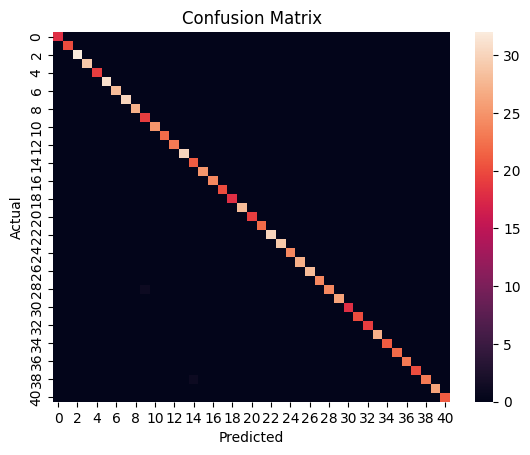

In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Optional: Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [70]:
import pickle

# Save the model
with open('disease_prediction_model.pkl', 'wb') as f:
    pickle.dump(model, f)